In [1]:
### imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
### config

load_dotenv()

USER = os.getenv("DB_USER")
PASS = os.getenv("DB_PASS")
HOST = os.getenv("DB_HOST")
DB = os.getenv("DB")
PORT = os.getenv("DB_PORT")

# quick check for variable correctness
# print(f"postgresql://{USER}:{PASS}@{HOST}:{PORT}/{DB}")

conn = f"postgresql://{USER}:{PASS}@{HOST}:{PORT}/{DB}"

engine = create_engine(conn)

# read in our TN population data
pop = pd.read_csv("./tn_population.csv")

In [3]:
### create some queries and run em
q_od = 'SELECT * FROM overdose_deaths'
q_TN_county = "SELECT * FROM fips_county WHERE state = 'TN'"
q_od_joined = """
    select c.county, od.year, od.overdose_deaths
    from overdose_deaths od
    join fips_county c 
    on c.fipscounty = od.fipscounty
    """
q_od_joined2 = """
    select 
        c.fipscounty,
        c.county,
        c.state,
        od.year,
        od.overdose_deaths
    from overdose_deaths od
    join fips_county c 
        on c.fipscounty = od.fipscounty
    where c.state = 'TN'
"""

with engine.connect() as connection:
    od = pd.read_sql(text(q_od), con = connection) 
    TN_county = pd.read_sql(text(q_TN_county), con = connection)
    od_TN_county = pd.read_sql(text(q_od_joined), con = connection)
    od_TN_county2 = pd.read_sql(text(q_od_joined2), con = connection)
    
#sorted(od_TN_county2["year"].unique())
od_TN_county2

,fipscounty,county,state,year,overdose_deaths
0,47001,ANDERSON,TN,2018,18
1,47001,ANDERSON,TN,2017,34
2,47001,ANDERSON,TN,2016,24
3,47001,ANDERSON,TN,2015,20
4,47003,BEDFORD,TN,2018,7
...,...,...,...,...,...
375,47187,WILLIAMSON,TN,2015,21
376,47189,WILSON,TN,2018,19
377,47189,WILSON,TN,2017,26
378,47189,WILSON,TN,2016,27


# 1 - 
Deaths over time. a. How has total overdose deaths changed over time? b. How have overdose deaths changed over time for Davidson and Shelby counties. c. Are there any counties in which overdose deaths are trending downward?

# Overdose Deaths in TN 2015-2018

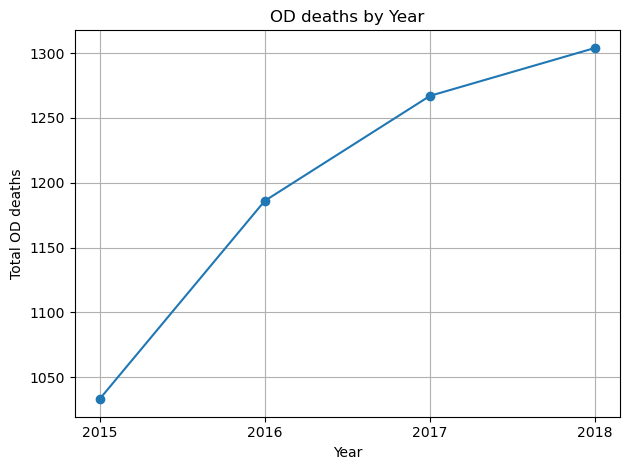

In [4]:
### plot OD deaths by year for TN
## get od deaths by year
od_TN_by_year = od_TN_county2.groupby('year', as_index=False)['overdose_deaths'].sum()
od_TN_by_year
plt.figure()
plt.plot(od_TN_by_year['year'], od_TN_by_year['overdose_deaths'], marker='o')
#plt.bar(od_by_year['year'], od_by_year['overdose_deaths'])

plt.xlabel('Year')
plt.ylabel('Total OD deaths')
plt.title('OD deaths by Year')

## get unique year cause I dont like 2015.5
years = sorted(od_TN_by_year["year"].unique())
plt.xticks(years)

plt.grid()
plt.tight_layout()

plt.show()

In [5]:
### return sql for ONLY davidson and shelby counties
q = """
    select *
    from overdose_deaths od
    join fips_county c
    on c.fipscounty = od.fipscounty
    where c.county = 'DAVIDSON' or c.county = 'SHELBY'
    """

with engine.connect() as connection:
    davidson_shelby = pd.read_sql(text(q), con = connection) 

davidson_shelby

,overdose_deaths,year,fipscounty,county,state,fipscounty,fipsstate
0,135,2015,47157,SHELBY,TN,47157,47
1,150,2016,47157,SHELBY,TN,47157,47
2,159,2017,47157,SHELBY,TN,47157,47
3,123,2018,47157,SHELBY,TN,47157,47
4,127,2015,47037,DAVIDSON,TN,47037,47
5,178,2016,47037,DAVIDSON,TN,47037,47
6,184,2017,47037,DAVIDSON,TN,47037,47
7,200,2018,47037,DAVIDSON,TN,47037,47


In [6]:
### split up each county for graph
davidson = davidson_shelby[davidson_shelby["county"] == "DAVIDSON"]
shelby = davidson_shelby[davidson_shelby["county"] == "SHELBY"]

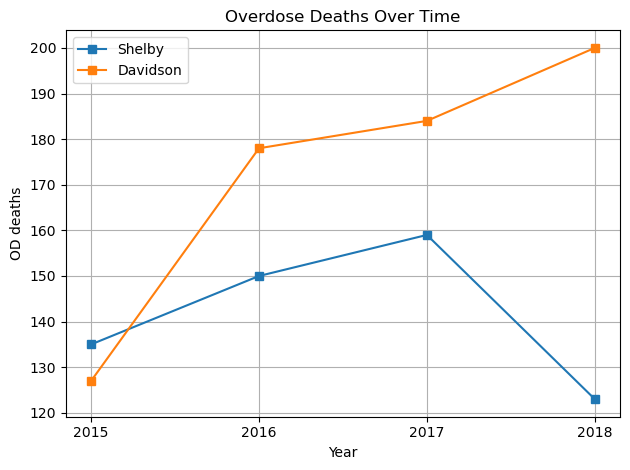

In [7]:
### plot both lines onto chart
plt.plot(shelby["year"], shelby["overdose_deaths"], marker="s", label="Shelby")
plt.plot(davidson["year"], davidson["overdose_deaths"], marker="s", label="Davidson")

## labels
plt.xlabel("Year")
plt.ylabel("OD deaths")
plt.title("Overdose Deaths Over Time")

## get unique year cause I dont like 2015.5
years = sorted(shelby["year"].unique())
plt.xticks(years)

## never see much diff when I add this but it's reassuring
plt.tight_layout()

## label the lines
plt.legend()
plt.grid()

plt.show()

# Overdose deaths by TN county

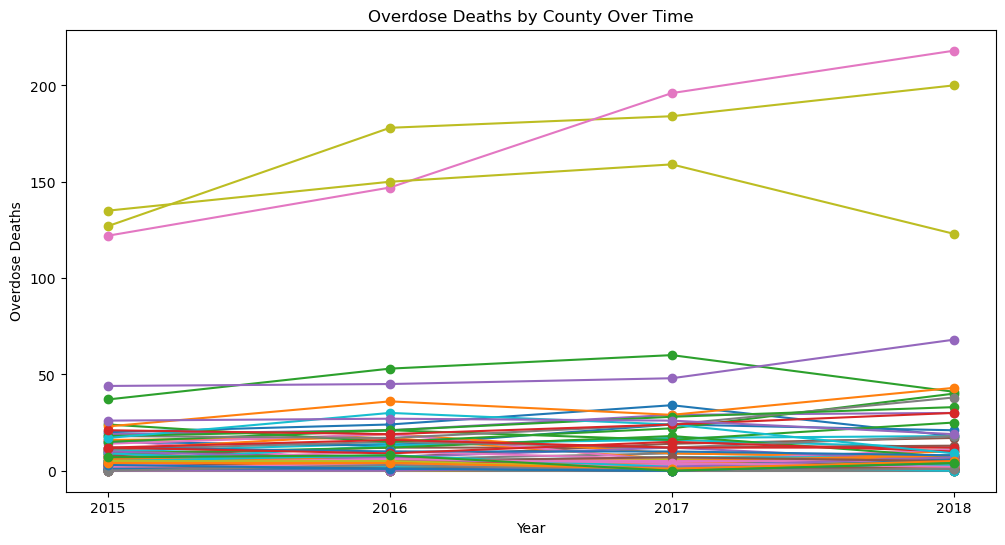

In [8]:
### make pivot from TN county data
pivot = od_TN_county2.pivot(index="year", columns="county", values="overdose_deaths")

pivot = pivot.sort_index()

## make the plot
pivot.plot(marker="o", figsize=(12, 6), legend=False)

## details
plt.xlabel("Year")
plt.ylabel("Overdose Deaths")
plt.title("Overdose Deaths by County Over Time")
## too many counties for this chart
#plt.legend(bbox_to_anchor=(1, 1))
plt.xticks(pivot.index)

# print(pivot)

plt.show()

# Top 10 counties in Overdose Deaths

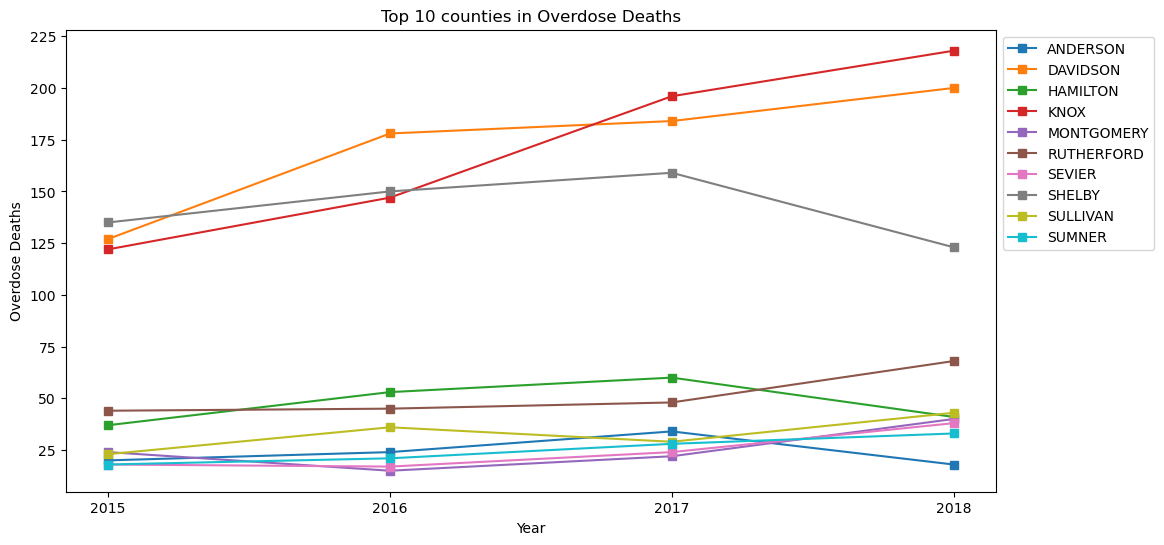

In [9]:
# find top 10 counties by top overdose deaths
top10_counties = (
    od_TN_county2.groupby("county")["overdose_deaths"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index
)
#print(top10_counties)

df_TN_top10 = od_TN_county2[od_TN_county2["county"].isin(top10_counties)]

pivot = df_TN_top10.pivot(index="year", columns="county", values="overdose_deaths").sort_index()

pivot.plot(marker="s", figsize=(12,6))

plt.xlabel("Year")
plt.ylabel("Overdose Deaths")
plt.title("Top 10 counties in Overdose Deaths")
plt.xticks(pivot.index)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.show()

# _________________________________________________________

In [10]:
### create some queries and run em
## I don't think this is very good practice as I'm fetching
## a lot (relatively speaking) of rows at once.
q_drug = "SELECT * FROM drug"
q_rx = "SELECT * FROM prescription"
q_prescriber = "SELECT * FROM prescriber"
q_zip_fips = "SELECT * FROM zip_fips"
q_fips_county = "SELECT * FROM fips_county"


with engine.connect() as connection:
    drug = pd.read_sql(text(q_drug), con = connection) 
    rx = pd.read_sql(text(q_rx), con = connection)
    prescriber = pd.read_sql(text(q_prescriber), con = connection)
    zip_fips = pd.read_sql(text(q_zip_fips), con = connection)
    fips_county = pd.read_sql(text(q_fips_county), con = connection)

In [11]:
### pd.merge rx and drug 
rx_drug_names = pd.merge(rx, drug, left_on='drug_name', right_on='drug_name', how='inner')
rx_drug_names

,npi,drug_name,bene_count,total_claim_count,total_30_day_fill_count,total_day_supply,total_drug_cost,bene_count_ge65,bene_count_ge65_suppress_flag,total_claim_count_ge65,ge65_suppress_flag,total_30_day_fill_count_ge65,total_day_supply_ge65,total_drug_cost_ge65,generic_name,opioid_drug_flag,long_acting_opioid_drug_flag,antibiotic_drug_flag,antipsychotic_drug_flag
0,1.427076e+09,RALOXIFENE HCL,NaN,18.0,28.0,840.0,1009.66,NaN,*,18.0,None,28.0,840.0,1009.66,RALOXIFENE HCL,N,N,N,N
1,1.003858e+09,GLIMEPIRIDE,NaN,12.0,16.0,480.0,270.86,NaN,*,NaN,*,NaN,NaN,NaN,GLIMEPIRIDE,N,N,N,N
2,1.184627e+09,TAMSULOSIN HCL,NaN,14.0,24.0,698.0,353.62,NaN,#,NaN,#,NaN,NaN,NaN,TAMSULOSIN HCL,N,N,N,N
3,1.306111e+09,SPIRIVA,NaN,13.0,13.0,390.0,4783.28,NaN,*,NaN,*,NaN,NaN,NaN,TIOTROPIUM BROMIDE,N,N,N,N
4,1.285658e+09,SPIRIVA,NaN,13.0,13.0,390.0,4855.95,NaN,#,NaN,#,NaN,NaN,NaN,TIOTROPIUM BROMIDE,N,N,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705010,1.336170e+09,PROMETHAZINE HCL,NaN,11.0,11.0,56.0,62.82,NaN,*,NaN,*,NaN,NaN,NaN,PROMETHAZINE HCL,N,N,N,N
705011,1.679676e+09,RANITIDINE HCL,53.0,178.0,426.0,12760.0,2860.16,NaN,#,NaN,#,NaN,NaN,NaN,RANITIDINE HCL,N,N,N,N
705012,1.265588e+09,DIAZEPAM,16.0,48.0,48.0,1425.0,253.49,NaN,*,14.0,None,14.0,420.0,55.49,DIAZEPAM,N,N,N,N
705013,1.144212e+09,RAMIPRIL,NaN,38.0,90.0,2700.0,627.50,NaN,#,NaN,#,NaN,NaN,NaN,RAMIPRIL,N,N,N,N


In [12]:
### merge prescribers with the previously merged prescription/drug names
rx_provider_join = pd.merge(prescriber, rx_drug_names, left_on='npi', right_on='npi', how='right')
rx_provider_join['npi'] = rx_provider_join['npi'].astype(int)
rx_provider_join

,npi,nppes_provider_last_org_name,nppes_provider_first_name,nppes_provider_mi,nppes_credentials,nppes_provider_gender,nppes_entity_code,nppes_provider_street1,nppes_provider_street2,nppes_provider_city,...,total_claim_count_ge65,ge65_suppress_flag,total_30_day_fill_count_ge65,total_day_supply_ge65,total_drug_cost_ge65,generic_name,opioid_drug_flag,long_acting_opioid_drug_flag,antibiotic_drug_flag,antipsychotic_drug_flag
0,1427075894,CHOUNZOM,TENZING,None,MD,F,I,15 S CENTRAL AVE,None,MONTEAGLE,...,18.0,None,28.0,840.0,1009.66,RALOXIFENE HCL,N,N,N,N
1,1003858150,LUCKEY,CAROL,R,NP,F,I,120 E CHURCH ST,None,LEXINGTON,...,NaN,*,NaN,NaN,NaN,GLIMEPIRIDE,N,N,N,N
2,1184627192,WHITE,KATHY,Y,FNP,F,I,1955 S 3RD ST,None,MEMPHIS,...,NaN,#,NaN,NaN,NaN,TAMSULOSIN HCL,N,N,N,N
3,1306111497,HELMER,BROOK,None,M.D.,F,I,1222 TROTWOOD AVE,SUITE 108,COLUMBIA,...,NaN,*,NaN,NaN,NaN,TIOTROPIUM BROMIDE,N,N,N,N
4,1285658237,LYONS,DARRIN,None,M.D.,M,I,7243 HIGHWAY 64,None,OAKLAND,...,NaN,#,NaN,NaN,NaN,TIOTROPIUM BROMIDE,N,N,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705010,1336169804,LORENZO-RIVERO,SHAUNA,None,M.D.,F,I,2108 E 3RD ST,SUITE 200,CHATTANOOGA,...,NaN,*,NaN,NaN,NaN,PROMETHAZINE HCL,N,N,N,N
705011,1679676282,MUNN,CHARLES,W,MD,M,I,6570 SUMMER OAKS COVE,None,BARTLETT,...,NaN,#,NaN,NaN,NaN,RANITIDINE HCL,N,N,N,N
705012,1265587992,CARTER,THOMAS,M,M.D.,M,I,110 29TH AVE N STE 202,None,NASHVILLE,...,14.0,None,14.0,420.0,55.49,DIAZEPAM,N,N,N,N
705013,1144211830,MIRE,RYAN,D,M.D.,M,I,4230 HARDING PIKE STE 601,None,NASHVILLE,...,NaN,#,NaN,NaN,NaN,RAMIPRIL,N,N,N,N


In [13]:
### make zip code columns of the same type to survive merge
zip_fips['zip'] = zip_fips['zip'].astype('Int64')
rx_provider_join['nppes_provider_zip5'] = rx_provider_join['nppes_provider_zip5'].astype('Int64')
rx_provider_county_join = pd.merge(rx_provider_join, zip_fips, left_on='nppes_provider_zip5', right_on='zip', how='left')
#rx_provider_county_join['fipscounty'] = rx_provider_county_join['fipscounty'].astype(int)
#rx_provider_county_join.dtypes

In [14]:
fips_county['fipscounty'] = fips_county['fipscounty'].astype('Int64')
rx_provider_county_join['fipscounty'] = rx_provider_county_join['fipscounty'].astype('Int64')
rx_provider_full = pd.merge(rx_provider_county_join, fips_county, left_on='fipscounty', right_on='fipscounty', how='left')
rx_provider_full

,npi,nppes_provider_last_org_name,nppes_provider_first_name,nppes_provider_mi,nppes_credentials,nppes_provider_gender,nppes_entity_code,nppes_provider_street1,nppes_provider_street2,nppes_provider_city,...,antipsychotic_drug_flag,zip,fipscounty,res_ratio,bus_ratio,oth_ratio,tot_ratio,county,state,fipsstate
0,1427075894,CHOUNZOM,TENZING,None,MD,F,I,15 S CENTRAL AVE,None,MONTEAGLE,...,N,37356,47115,0.475294,0.642202,0.222222,0.485021,MARION,TN,47
1,1427075894,CHOUNZOM,TENZING,None,MD,F,I,15 S CENTRAL AVE,None,MONTEAGLE,...,N,37356,47061,0.509804,0.357798,0.777778,0.501427,GRUNDY,TN,47
2,1427075894,CHOUNZOM,TENZING,None,MD,F,I,15 S CENTRAL AVE,None,MONTEAGLE,...,N,37356,47051,0.014902,0.000000,0.000000,0.013552,FRANKLIN,TN,47
3,1003858150,LUCKEY,CAROL,R,NP,F,I,120 E CHURCH ST,None,LEXINGTON,...,N,38351,47077,0.996015,0.998804,1.000000,0.996312,HENDERSON,TN,47
4,1003858150,LUCKEY,CAROL,R,NP,F,I,120 E CHURCH ST,None,LEXINGTON,...,N,38351,47113,0.003985,0.001196,0.000000,0.003688,MADISON,TN,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1170925,1336169804,LORENZO-RIVERO,SHAUNA,None,M.D.,F,I,2108 E 3RD ST,SUITE 200,CHATTANOOGA,...,N,37404,47065,1.000000,1.000000,1.000000,1.000000,HAMILTON,TN,47
1170926,1679676282,MUNN,CHARLES,W,MD,M,I,6570 SUMMER OAKS COVE,None,BARTLETT,...,N,38134,47157,1.000000,1.000000,1.000000,1.000000,SHELBY,TN,47
1170927,1265587992,CARTER,THOMAS,M,M.D.,M,I,110 29TH AVE N STE 202,None,NASHVILLE,...,N,37203,47037,1.000000,1.000000,1.000000,1.000000,DAVIDSON,TN,47
1170928,1144211830,MIRE,RYAN,D,M.D.,M,I,4230 HARDING PIKE STE 601,None,NASHVILLE,...,N,37205,47037,1.000000,1.000000,1.000000,1.000000,DAVIDSON,TN,47


In [15]:
### Copy opioid merged tables for edits
## keep only opioid rows and store
opioids = rx_provider_full[rx_provider_full["opioid_drug_flag"] == "Y"].copy()
opioids_by_county = rx_provider_join.merge(
    zip_fips,
    left_on="nppes_provider_zip5",
    right_on="zip",
    how="left"
)
opioids_by_county = opioids_by_county[opioids_by_county["opioid_drug_flag"] == "Y"]
opioids_by_county = opioids_by_county[opioids_by_county["nppes_provider_state"] == "TN"]

## npi displays scientific notation cause it's a float
# ultimately change to str as it's an identifier and we wont' be doing math on it 
opioids["npi"] = opioids["npi"].astype("Int64").astype(str)

## store in new var, grouped version of our opioids   
top10_opioid_prescribers = (
    opioids
    .groupby(
        [
            "npi",
            "nppes_provider_last_org_name",
            "nppes_provider_first_name",
            "specialty_description",
            "county",
            "nppes_provider_city",
            "nppes_provider_state",
            "nppes_provider_zip5",
        ],
        dropna=False
    )["total_claim_count"]
    .sum()
    .reset_index(name="opioid_claims")
    .sort_values("opioid_claims", ascending=False)
    .head(10)
)

top10_opioid_prescribers

,npi,nppes_provider_last_org_name,nppes_provider_first_name,specialty_description,county,nppes_provider_city,nppes_provider_state,nppes_provider_zip5,opioid_claims
16274,1912011792,COFFEY,DAVID,Family Practice,SCOTT,ONEIDA,TN,37841,9275.0
16097,1891915047,KINDRICK,JUSTIN,Nurse Practitioner,CUMBERLAND,CROSSVILLE,TN,38555,8405.0
8045,1447608211,CATHERS,SHARON,Nurse Practitioner,KNOX,KNOXVILLE,TN,37923,7274.0
9720,1538428230,PAINTER,MICHELLE,Nurse Practitioner,SULLIVAN,BRISTOL,TN,37620,5709.0
17167,1962406793,CLARK,RICHARD,Internal Medicine,FENTRESS,JAMESTOWN,TN,38556,5607.0
17168,1962406793,CLARK,RICHARD,Internal Medicine,PICKETT,JAMESTOWN,TN,38556,5607.0
11001,1609879527,LADSON,JAMES,Anesthesiology,RUTHERFORD,MURFREESBORO,TN,37128,5423.0
10759,1598746554,WILLETT,DWIGHT,Family Practice,ROANE,KINGSTON,TN,37763,5221.0
15576,1861892424,TAYLOR,ALICIA,Physician Assistant,CAMPBELL,LA FOLLETTE,TN,37766,5088.0
16698,1932279429,BOWSER,AMY,Nurse Practitioner,SUMNER,GALLATIN,TN,37066,4979.0


In [16]:
top10_opioid_prescribers["prescriber"] = (
    top10_opioid_prescribers["nppes_provider_last_org_name"].fillna("") + ", " +
    top10_opioid_prescribers["nppes_provider_first_name"].fillna("")
)

top10_opioid_prescribers["opioid_claims"] = top10_opioid_prescribers["opioid_claims"].astype("Int64")

top10_opioid_prescribers = top10_opioid_prescribers[
    [
        "npi",
        "prescriber",
        "specialty_description",
        "county",
        "nppes_provider_city",
        "nppes_provider_state",
        "nppes_provider_zip5",
        "opioid_claims",
    ]
]

top10_opioid_prescribers

,npi,prescriber,specialty_description,county,nppes_provider_city,nppes_provider_state,nppes_provider_zip5,opioid_claims
16274,1912011792,"COFFEY, DAVID",Family Practice,SCOTT,ONEIDA,TN,37841,9275
16097,1891915047,"KINDRICK, JUSTIN",Nurse Practitioner,CUMBERLAND,CROSSVILLE,TN,38555,8405
8045,1447608211,"CATHERS, SHARON",Nurse Practitioner,KNOX,KNOXVILLE,TN,37923,7274
9720,1538428230,"PAINTER, MICHELLE",Nurse Practitioner,SULLIVAN,BRISTOL,TN,37620,5709
17167,1962406793,"CLARK, RICHARD",Internal Medicine,FENTRESS,JAMESTOWN,TN,38556,5607
17168,1962406793,"CLARK, RICHARD",Internal Medicine,PICKETT,JAMESTOWN,TN,38556,5607
11001,1609879527,"LADSON, JAMES",Anesthesiology,RUTHERFORD,MURFREESBORO,TN,37128,5423
10759,1598746554,"WILLETT, DWIGHT",Family Practice,ROANE,KINGSTON,TN,37763,5221
15576,1861892424,"TAYLOR, ALICIA",Physician Assistant,CAMPBELL,LA FOLLETTE,TN,37766,5088
16698,1932279429,"BOWSER, AMY",Nurse Practitioner,SUMNER,GALLATIN,TN,37066,4979


In [17]:
### that npi is clark and he has atleast 2 counties
top10_opioid_prescribers["npi"].value_counts().head()

npi
1962406793    2
1912011792    1
1891915047    1
1447608211    1
1538428230    1
Name: count, dtype: int64

In [18]:
### we are given a tot_ratio (ratio for prescriber claims within 'x' county) to multiply 
### so that we know what pct of claims went to what county
opioids_by_county["weighted_claims"] = (opioids_by_county["total_claim_count"] * opioids_by_county["tot_ratio"])
opioids_by_county

,npi,nppes_provider_last_org_name,nppes_provider_first_name,nppes_provider_mi,nppes_credentials,nppes_provider_gender,nppes_entity_code,nppes_provider_street1,nppes_provider_street2,nppes_provider_city,...,long_acting_opioid_drug_flag,antibiotic_drug_flag,antipsychotic_drug_flag,zip,fipscounty,res_ratio,bus_ratio,oth_ratio,tot_ratio,weighted_claims
81,1659797769,HILL,PIPER,S,FNP-C,F,I,102 DUNHILL PL NW,None,CLEVELAND,...,N,N,N,37311,47011,0.996995,1.000000,0.997940,0.997417,523.643925
82,1659797769,HILL,PIPER,S,FNP-C,F,I,102 DUNHILL PL NW,None,CLEVELAND,...,N,N,N,37311,47065,0.003005,0.000000,0.002060,0.002583,1.356075
115,1003954595,JACKS,BEVERLY,J,"CNM, APRN",F,I,6116 SHALLOWFORD RD,SUITE 117,CHATTANOOGA,...,N,N,N,37421,47065,1.000000,1.000000,1.000000,1.000000,79.000000
366,1487941522,NGO,PAUL,J,D.O,M,I,1005 DR DB TODD JR BLVD,None,NASHVILLE,...,N,N,N,37208,47037,1.000000,1.000000,1.000000,1.000000,12.000000
383,1295730281,DRAKE,ALAN,R,M.D.,M,I,133 CHURCHILL DR,None,SPARTA,...,N,N,N,38583,47035,0.044379,0.007609,0.189189,0.042635,1.108510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1170881,1558545780,LONG,BETH,R,FNP,F,I,4022 LIBERTY ST,None,MILAN,...,N,N,N,38358,47053,0.997604,1.000000,1.000000,0.997894,21.953668
1170882,1558545780,LONG,BETH,R,FNP,F,I,4022 LIBERTY ST,None,MILAN,...,N,N,N,38358,47017,0.002396,0.000000,0.000000,0.002106,0.046332
1170912,1942324470,SIMPSON,LATANYA,A,M.D.,F,I,4940 HIGHWAY 57,None,ROSSVILLE,...,N,N,N,38066,47047,1.000000,1.000000,1.000000,1.000000,13.000000
1170918,1083001606,LANDOWSKI,CHRISTINA,None,FNP-C,F,I,201 E 10TH ST,None,SOUTH PITTSBURG,...,N,N,N,37380,47051,0.003653,0.000000,0.000000,0.003237,0.090636


In [19]:
opioids_by_county["prescriber"] = (
    opioids_by_county["nppes_provider_first_name"].fillna("") + " " +
    opioids_by_county["nppes_provider_last_org_name"].fillna("")
)
opioids_by_county = opioids_by_county[opioids_by_county["nppes_provider_state"] == "TN"]

In [20]:
provider_county = (
    opioids_by_county
    .groupby(
        [
            "fipscounty",
            "npi",
            "prescriber",
            "specialty_description",
            "nppes_provider_city",
            "nppes_provider_state",
            "nppes_provider_zip5",
        ],
        dropna=False
    )["weighted_claims"]
    .sum()
    .reset_index()
)
provider_county

,fipscounty,npi,prescriber,specialty_description,nppes_provider_city,nppes_provider_state,nppes_provider_zip5,weighted_claims
0,13027,1700146107,STEVEN COWART,Orthopedic Surgery,CHATTANOOGA,TN,31643,20.000000
1,47001,1003044033,CHARLES BENSON,Orthopedic Surgery,OAK RIDGE,TN,37830,188.045760
2,47001,1003936436,DALE PITTENGER,Dentist,KNOXVILLE,TN,37931,0.639954
3,47001,1003992421,DEBORAH GRAF,Nurse Practitioner,POWELL,TN,37849,9.264970
4,47001,1013252998,MOLLY MCGILL,Nurse Practitioner,KNOXVILLE,TN,37938,0.182548
...,...,...,...,...,...,...,...,...
17867,NaN,1891114260,NICHOLAS BECKMANN,Student in an Organized Health Care Education/...,MEMPHIS,TN,38163,0.000000
17868,NaN,1891746541,GREGORY HARDERS,Emergency Medicine,MURFREESBORO,TN,39129,0.000000
17869,NaN,1952789430,MARK ILTIS,Student in an Organized Health Care Education/...,MEMPHIS,TN,38163,0.000000
17870,NaN,1972959211,COLE LOCKLEAR,Student in an Organized Health Care Education/...,MEMPHIS,TN,38163,0.000000


In [21]:
### give everyone a county rank based on weighted claims
provider_county["county_rank"] = (
    provider_county
    .groupby("fipscounty")["weighted_claims"]
    .rank(method="first", ascending=False)
)
provider_county

,fipscounty,npi,prescriber,specialty_description,nppes_provider_city,nppes_provider_state,nppes_provider_zip5,weighted_claims,county_rank
0,13027,1700146107,STEVEN COWART,Orthopedic Surgery,CHATTANOOGA,TN,31643,20.000000,1.0
1,47001,1003044033,CHARLES BENSON,Orthopedic Surgery,OAK RIDGE,TN,37830,188.045760,40.0
2,47001,1003936436,DALE PITTENGER,Dentist,KNOXVILLE,TN,37931,0.639954,237.0
3,47001,1003992421,DEBORAH GRAF,Nurse Practitioner,POWELL,TN,37849,9.264970,206.0
4,47001,1013252998,MOLLY MCGILL,Nurse Practitioner,KNOXVILLE,TN,37938,0.182548,246.0
...,...,...,...,...,...,...,...,...,...
17867,NaN,1891114260,NICHOLAS BECKMANN,Student in an Organized Health Care Education/...,MEMPHIS,TN,38163,0.000000,NaN
17868,NaN,1891746541,GREGORY HARDERS,Emergency Medicine,MURFREESBORO,TN,39129,0.000000,NaN
17869,NaN,1952789430,MARK ILTIS,Student in an Organized Health Care Education/...,MEMPHIS,TN,38163,0.000000,NaN
17870,NaN,1972959211,COLE LOCKLEAR,Student in an Organized Health Care Education/...,MEMPHIS,TN,38163,0.000000,NaN


In [22]:
### check for ONLY opioids
opioids_by_county["opioid_drug_flag"].value_counts(dropna=False)

opioid_drug_flag
Y    52670
Name: count, dtype: int64

In [23]:
top_prescriber_per_county = (
    provider_county[provider_county["county_rank"] == 1]
    .sort_values(["weighted_claims"], ascending=[False])
)
fips_county["fipscounty"] = fips_county["fipscounty"].astype('Int64')
top_prescriber_per_county["fipscounty"] = top_prescriber_per_county["fipscounty"].astype('Int64')
top_prescriber_per_county = pd.merge(top_prescriber_per_county, fips_county, left_on='fipscounty', right_on='fipscounty', how='left')

In [24]:
### ensure again we only have 47 (TN)
top_prescriber_per_county = top_prescriber_per_county[
    top_prescriber_per_county["fipsstate"] == '47'
]
top_prescriber_per_county

,fipscounty,npi,prescriber,specialty_description,nppes_provider_city,nppes_provider_state,nppes_provider_zip5,weighted_claims,county_rank,county,state,fipsstate
0,47151,1912011792,DAVID COFFEY,Family Practice,ONEIDA,TN,37841,9275.000000,1.0,SCOTT,TN,47
1,47035,1891915047,JUSTIN KINDRICK,Nurse Practitioner,CROSSVILLE,TN,38555,8405.000000,1.0,CUMBERLAND,TN,47
2,47093,1447608211,SHARON CATHERS,Nurse Practitioner,KNOXVILLE,TN,37923,7274.000000,1.0,KNOX,TN,47
3,47163,1538428230,MICHELLE PAINTER,Nurse Practitioner,BRISTOL,TN,37620,5709.000000,1.0,SULLIVAN,TN,47
4,47049,1962406793,RICHARD CLARK,Internal Medicine,JAMESTOWN,TN,38556,5588.653896,1.0,FENTRESS,TN,47
...,...,...,...,...,...,...,...,...,...,...,...,...
90,47111,1205826526,HANNA ILIA,Emergency Medicine,LAFAYETTE,TN,37083,606.000000,1.0,MACON,TN,47
91,47161,1851327977,CHRISTA BLANE,Nurse Practitioner,DOVER,TN,37058,594.000000,1.0,STEWART,TN,47
92,47121,1306221213,JANET REECE,Nurse Practitioner,DECATUR,TN,37322,574.902936,1.0,MEIGS,TN,47
93,47067,1356794515,KANDI REECE,Nurse Practitioner,SNEEDVILLE,TN,37869,309.355910,1.0,HANCOCK,TN,47


In [25]:
### fetch the top10 based on weighted claims for each county
top10 = top_prescriber_per_county.sort_values("weighted_claims", ascending=False).head(10)
top10

,fipscounty,npi,prescriber,specialty_description,nppes_provider_city,nppes_provider_state,nppes_provider_zip5,weighted_claims,county_rank,county,state,fipsstate
0,47151,1912011792,DAVID COFFEY,Family Practice,ONEIDA,TN,37841,9275.000000,1.0,SCOTT,TN,47
1,47035,1891915047,JUSTIN KINDRICK,Nurse Practitioner,CROSSVILLE,TN,38555,8405.000000,1.0,CUMBERLAND,TN,47
2,47093,1447608211,SHARON CATHERS,Nurse Practitioner,KNOXVILLE,TN,37923,7274.000000,1.0,KNOX,TN,47
3,47163,1538428230,MICHELLE PAINTER,Nurse Practitioner,BRISTOL,TN,37620,5709.000000,1.0,SULLIVAN,TN,47
4,47049,1962406793,RICHARD CLARK,Internal Medicine,JAMESTOWN,TN,38556,5588.653896,1.0,FENTRESS,TN,47
5,47149,1609879527,JAMES LADSON,Anesthesiology,MURFREESBORO,TN,37128,5423.000000,1.0,RUTHERFORD,TN,47
6,47145,1598746554,DWIGHT WILLETT,Family Practice,KINGSTON,TN,37763,5221.000000,1.0,ROANE,TN,47
7,47013,1861892424,ALICIA TAYLOR,Physician Assistant,LA FOLLETTE,TN,37766,5088.000000,1.0,CAMPBELL,TN,47
8,47165,1932279429,AMY BOWSER,Nurse Practitioner,GALLATIN,TN,37066,4979.000000,1.0,SUMNER,TN,47
9,47157,1255670576,SHERYL KIRK,Nurse Practitioner,CORDOVA,TN,38018,4874.000000,1.0,SHELBY,TN,47


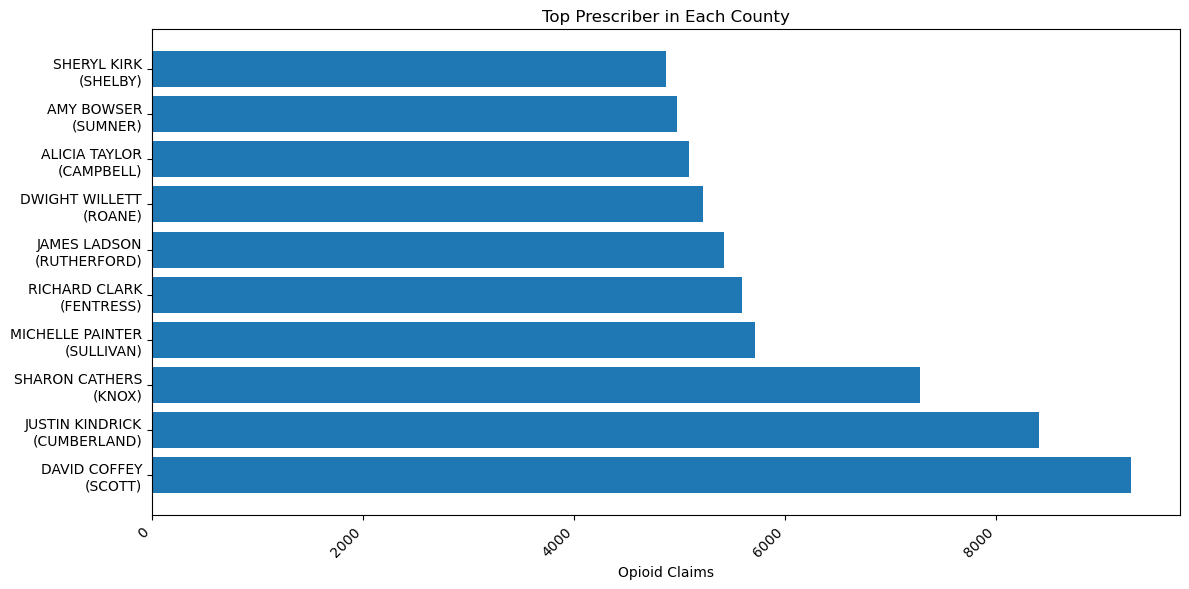

In [49]:
top10["xlabel"] = top10["prescriber"] + "\n(" + top10["county"] + ")"

plt.figure(figsize=(12, 6))
plt.barh(top10["xlabel"], top10["weighted_claims"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Opioid Claims")
plt.title("Top Prescriber in Each County")
plt.tight_layout()
plt.show()

In [53]:
opioids2 = rx_provider_full[rx_provider_full["opioid_drug_flag"] == "Y"].copy()
prescriber_drugs = (
    opioids2
    .groupby(["npi", "generic_name"])["total_claim_count"]
    .sum()
    .reset_index()
)
#prescriber_drugs

top_drug_by_prescriber = (
    prescriber_drugs
    .sort_values(["npi", "total_claim_count"], ascending=[True, False])
    .drop_duplicates(subset="npi")
)
#top_drug_by_prescriber

top10_with_top_drug = top10.merge(
    top_drug_by_prescriber,
    on="npi",
    how="left"
)
top10_with_top_drug

,fipscounty,npi,prescriber,specialty_description,nppes_provider_city,nppes_provider_state,nppes_provider_zip5,weighted_claims,county_rank,county,state,fipsstate,xlabel,generic_name,total_claim_count
0,47151,1912011792,DAVID COFFEY,Family Practice,ONEIDA,TN,37841,9275.000000,1.0,SCOTT,TN,47,DAVID COFFEY\n(SCOTT),OXYCODONE HCL,4538.0
1,47035,1891915047,JUSTIN KINDRICK,Nurse Practitioner,CROSSVILLE,TN,38555,8405.000000,1.0,CUMBERLAND,TN,47,JUSTIN KINDRICK\n(CUMBERLAND),OXYCODONE HCL,2774.0
2,47093,1447608211,SHARON CATHERS,Nurse Practitioner,KNOXVILLE,TN,37923,7274.000000,1.0,KNOX,TN,47,SHARON CATHERS\n(KNOX),OXYCODONE HCL,3233.0
3,47163,1538428230,MICHELLE PAINTER,Nurse Practitioner,BRISTOL,TN,37620,5709.000000,1.0,SULLIVAN,TN,47,MICHELLE PAINTER\n(SULLIVAN),OXYCODONE HCL,1651.0
4,47049,1962406793,RICHARD CLARK,Internal Medicine,JAMESTOWN,TN,38556,5588.653896,1.0,FENTRESS,TN,47,RICHARD CLARK\n(FENTRESS),OXYCODONE HCL,3986.0
5,47149,1609879527,JAMES LADSON,Anesthesiology,MURFREESBORO,TN,37128,5423.000000,1.0,RUTHERFORD,TN,47,JAMES LADSON\n(RUTHERFORD),HYDROCODONE/ACETAMINOPHEN,2173.0
6,47145,1598746554,DWIGHT WILLETT,Family Practice,KINGSTON,TN,37763,5221.000000,1.0,ROANE,TN,47,DWIGHT WILLETT\n(ROANE),HYDROCODONE/ACETAMINOPHEN,2408.0
7,47013,1861892424,ALICIA TAYLOR,Physician Assistant,LA FOLLETTE,TN,37766,5088.000000,1.0,CAMPBELL,TN,47,ALICIA TAYLOR\n(CAMPBELL),OXYCODONE HCL,3042.0
8,47165,1932279429,AMY BOWSER,Nurse Practitioner,GALLATIN,TN,37066,4979.000000,1.0,SUMNER,TN,47,AMY BOWSER\n(SUMNER),OXYCODONE HCL,1306.0
9,47157,1255670576,SHERYL KIRK,Nurse Practitioner,CORDOVA,TN,38018,4874.000000,1.0,SHELBY,TN,47,SHERYL KIRK\n(SHELBY),HYDROCODONE/ACETAMINOPHEN,1254.0


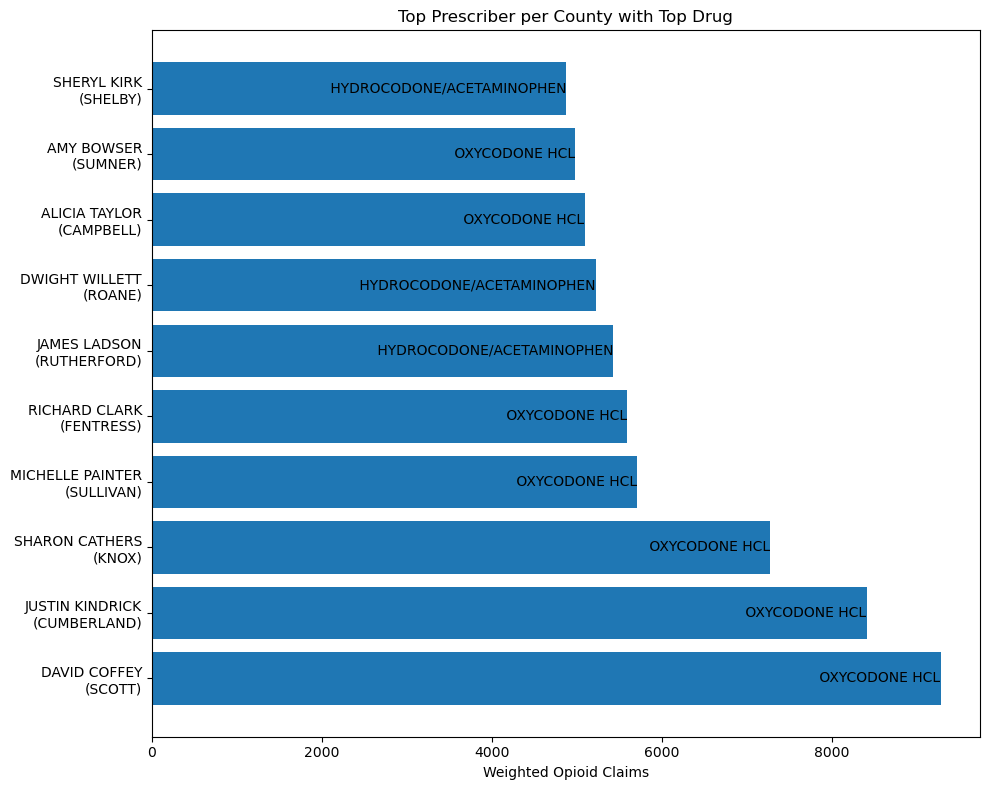

In [59]:
plt.figure(figsize=(10, 8))
bars = plt.barh(top10["xlabel"], top10_with_top_drug["weighted_claims"])

for i, row in top10_with_top_drug.iterrows():
    plt.text(
        row["weighted_claims"],
        i,
        f" {row['generic_name']}",
        va="center",
        ha="right"
    )

plt.xlabel("Weighted Opioid Claims")
plt.title("Top Prescriber per County with Top Drug")
plt.tight_layout()
plt.show()

In [66]:
opioid_counts = (
    opioids["generic_name"]
    .value_counts()
    .rename_axis("Drug")
    .reset_index(name="Count")
)
opioid_counts

,Drug,Count
0,HYDROCODONE/ACETAMINOPHEN,15728
1,OXYCODONE HCL/ACETAMINOPHEN,9467
2,TRAMADOL HCL,9256
3,OXYCODONE HCL,6052
4,MORPHINE SULFATE,3869
5,FENTANYL,2467
6,ACETAMINOPHEN WITH CODEINE,1929
7,OXYMORPHONE HCL,1136
8,HYDROMORPHONE HCL,604
9,METHADONE HCL,574


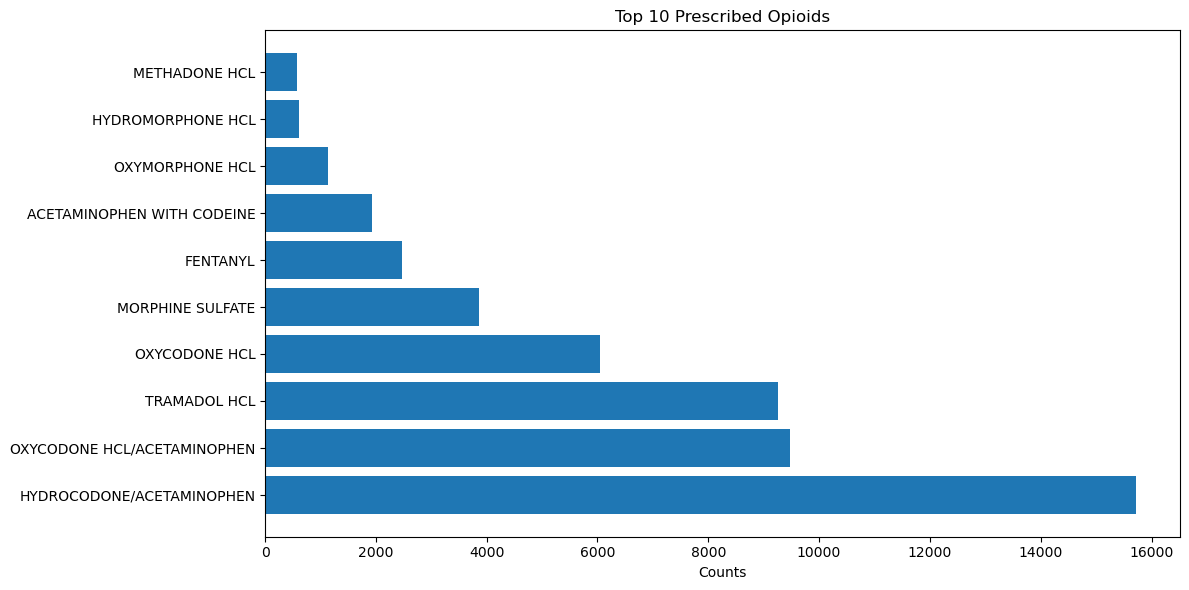

In [72]:
top_opioid_counts = opioid_counts.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_opioid_counts["Drug"], top_opioid_counts["Count"])
plt.xlabel("Counts")
plt.title("Top 10 Prescribed Opioids")
plt.tight_layout()
plt.show()

In [27]:
od_by_county = (
    od_TN_county2
    .groupby("fipscounty", as_index=False)["overdose_deaths"]
    .sum()
)
od_by_county

,fipscounty,overdose_deaths
0,47001,96
1,47003,19
2,47005,11
3,47007,8
4,47009,99
...,...,...
90,47181,8
91,47183,14
92,47185,19
93,47187,94


In [28]:
rx_by_county = top_prescriber_per_county[
    ["fipscounty", "weighted_claims"]
].copy()
rx_by_county

,fipscounty,weighted_claims
0,47151,9275.000000
1,47035,8405.000000
2,47093,7274.000000
3,47163,5709.000000
4,47049,5588.653896
...,...,...
90,47111,606.000000
91,47161,594.000000
92,47121,574.902936
93,47067,309.355910


In [29]:
fipscounty_lookup = fips_county[["fipscounty", "county"]].copy()
fipscounty_lookup = fipscounty_lookup.drop_duplicates(subset="fipscounty")
fipscounty_lookup

,fipscounty,county
0,1001,AUTAUGA
1,1003,BALDWIN
2,1005,BARBOUR
3,1007,BIBB
4,1009,BLOUNT
...,...,...
3267,72147,VIEQUES
3268,72149,VILLALBA
3269,72151,YABUCOA
3270,72153,YAUCO


In [30]:
county_analysis = pd.merge(
    rx_by_county,
    fipscounty_lookup,
    on="fipscounty",
    how="left"
)
county_analysis = pd.merge(county_analysis, od_by_county, on="fipscounty", how="left")

county_analysis["fipscounty"] = county_analysis["fipscounty"].astype("Int64")
fipscounty_lookup["fipscounty"] = fipscounty_lookup["fipscounty"].astype("Int64")

county_analysis["county"] = county_analysis["county"].str.replace(" ", "", regex=False)

county_analysis = county_analysis[["county", "overdose_deaths", "weighted_claims"]]
county_analysis

,county,overdose_deaths,weighted_claims
0,SCOTT,8,9275.000000
1,CUMBERLAND,24,8405.000000
2,KNOX,683,7274.000000
3,SULLIVAN,131,5709.000000
4,FENTRESS,6,5588.653896
...,...,...,...
90,MACON,12,606.000000
91,STEWART,8,594.000000
92,MEIGS,3,574.902936
93,HANCOCK,10,309.355910


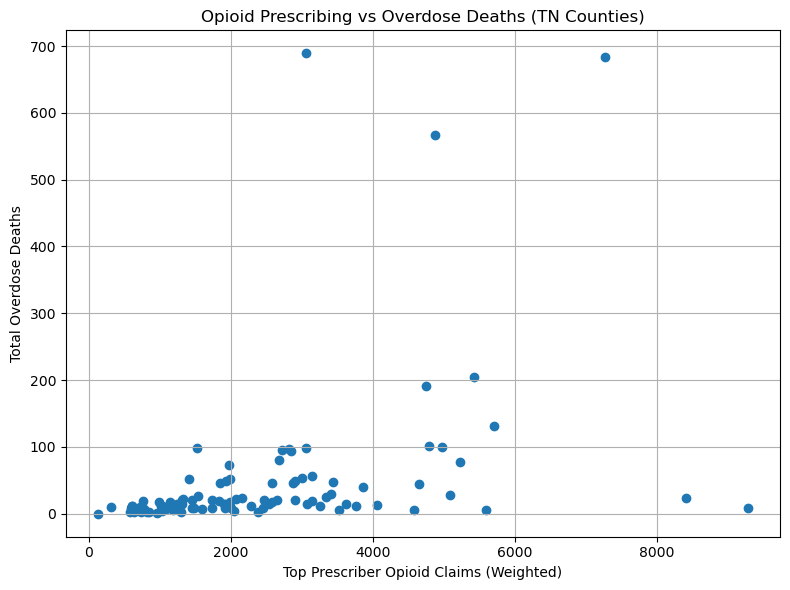

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    county_analysis["weighted_claims"],
    county_analysis["overdose_deaths"]
)

plt.xlabel("Top Prescriber Opioid Claims (Weighted)")
plt.ylabel("Total Overdose Deaths")
plt.title("Opioid Prescribing vs Overdose Deaths (TN Counties)")

plt.grid()
plt.tight_layout()
plt.show()

# Total Opioid Claims and Overdose Deaths by County

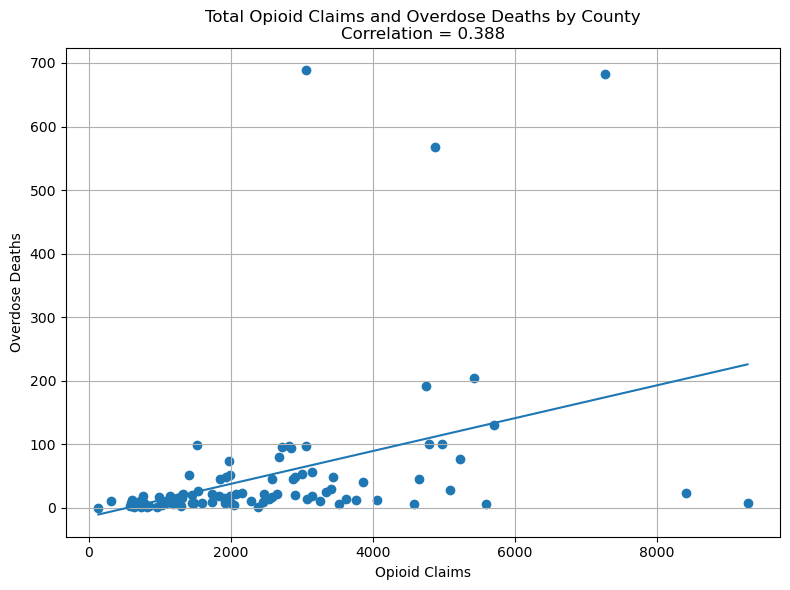

In [32]:
# raw
x_raw = county_analysis["weighted_claims"]
y_raw = county_analysis["overdose_deaths"]
m_raw, b_raw = np.polyfit(x_raw, y_raw, 1)
corr_raw = x_raw.corr(y_raw)
x_raw_sorted = np.sort(x_raw)

fig, ax = plt.subplots(figsize=(8, 6))

# left: raw
ax.scatter(x_raw, y_raw)
ax.plot(x_raw_sorted, m_raw * x_raw_sorted + b_raw)
ax.set_xlabel("Opioid Claims")
ax.set_ylabel("Overdose Deaths")
ax.set_title(f"Total Opioid Claims and Overdose Deaths by County\nCorrelation = {corr_raw:.3f}")
ax.grid()

plt.tight_layout()
plt.show()

In [33]:
county_analysis

,county,overdose_deaths,weighted_claims
0,SCOTT,8,9275.000000
1,CUMBERLAND,24,8405.000000
2,KNOX,683,7274.000000
3,SULLIVAN,131,5709.000000
4,FENTRESS,6,5588.653896
...,...,...,...
90,MACON,12,606.000000
91,STEWART,8,594.000000
92,MEIGS,3,574.902936
93,HANCOCK,10,309.355910


In [34]:
corr = county_analysis["weighted_claims"].corr(
    county_analysis["overdose_deaths"]
)

print(f"Correlation: {corr:.3f}")

Correlation: 0.388


In [35]:
county_totals = (
    opioids_by_county
    .groupby("fipscounty")["weighted_claims"]
    .sum()
    .reset_index(name="total_opioid_claims")
)

# od_by_county["fipscounty"] = od_by_county["fipscounty"].astype('Int64')
county_totals["fipscounty"] = county_totals["fipscounty"].astype('Int64')
fipscounty_lookup["fipscounty"] = fipscounty_lookup["fipscounty"].astype('Int64')

# county_analysis = pd.merge(
#     od_by_county,
#     county_totals,
#     on="fipscounty",
#     how="inner"
# )
county_totals = pd.merge(county_totals, fipscounty_lookup, on="fipscounty", how="left")
county_totals = county_totals[["county", "total_opioid_claims"]]
county_totals

,county,total_opioid_claims
0,BROOKS,20.000000
1,ANDERSON,34529.558475
2,BEDFORD,8399.666501
3,BENTON,10769.203211
4,BLEDSOE,3938.270267
...,...,...
92,WEAKLEY,16248.480507
93,WHITE,4991.410052
94,WILLIAMSON,39145.234616
95,WILSON,37620.717475


In [36]:
pop

,Name,Population
0,ANDERSON COUNTY,75129
1,BEDFORD COUNTY,45058
2,BENTON COUNTY,16489
3,BLEDSOE COUNTY,12876
4,BLOUNT COUNTY,123010
...,...,...
90,WAYNE COUNTY,17021
91,WEAKLEY COUNTY,35021
92,WHITE COUNTY,25841
93,WILLIAMSON COUNTY,202686


In [37]:
### bring in out TN population csv to add some clarity to the county size vs od
pop["county"] = pop["Name"].str.replace(" COUNTY", "", regex=False)
pop["county"] = pop["county"].str.replace(" ", "", regex=False)
pop = pop[["county","Population"]]
pop

,county,Population
0,ANDERSON,75129
1,BEDFORD,45058
2,BENTON,16489
3,BLEDSOE,12876
4,BLOUNT,123010
...,...,...
90,WAYNE,17021
91,WEAKLEY,35021
92,WHITE,25841
93,WILLIAMSON,202686


In [38]:
county_analysis = pd.merge(county_analysis, pop, on="county", how="left")
county_analysis

,county,overdose_deaths,weighted_claims,Population
0,SCOTT,8,9275.000000,22228
1,CUMBERLAND,24,8405.000000,56053
2,KNOX,683,7274.000000,432226
3,SULLIVAN,131,5709.000000,156823
4,FENTRESS,6,5588.653896,17959
...,...,...,...,...
90,MACON,12,606.000000,22248
91,STEWART,8,594.000000,13324
92,MEIGS,3,574.902936,11753
93,HANCOCK,10,309.355910,6819


In [39]:
county_analysis["claims_per_1k"] = (
    county_analysis["weighted_claims"] / county_analysis["Population"] * 1000
)

county_analysis["deaths_per_100k"] = (
    county_analysis["overdose_deaths"] / county_analysis["Population"] * 100000
)

county_analysis[
    ["county", "weighted_claims", "Population", "claims_per_1k",
     "overdose_deaths", "deaths_per_100k"]
].head()

,county,weighted_claims,Population,claims_per_1k,overdose_deaths,deaths_per_100k
0,SCOTT,9275.000000,22228,417.266511,8,35.990642
1,CUMBERLAND,8405.000000,56053,149.947371,24,42.816620
2,KNOX,7274.000000,432226,16.829159,683,158.019184
3,SULLIVAN,5709.000000,156823,36.404099,131,83.533665
4,FENTRESS,5588.653896,17959,311.189593,6,33.409433


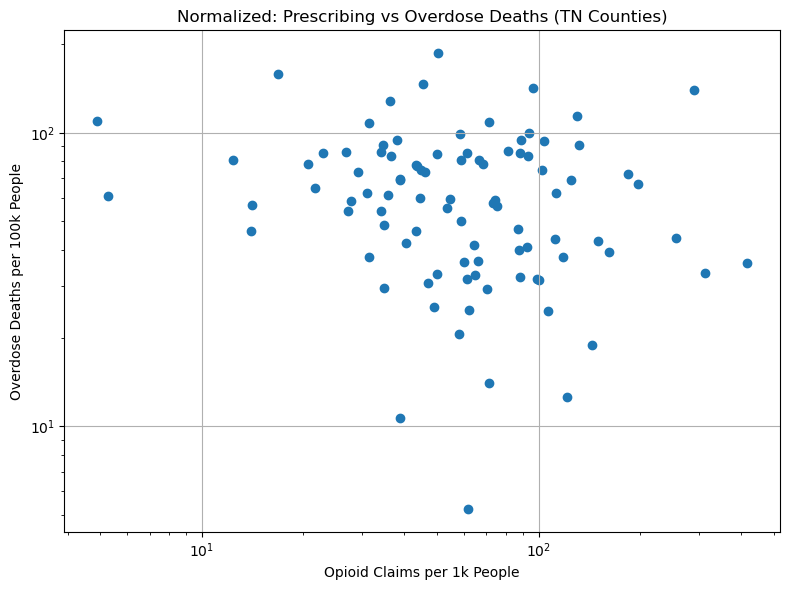

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    county_analysis["claims_per_1k"],
    county_analysis["deaths_per_100k"]
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Opioid Claims per 1k People")
plt.ylabel("Overdose Deaths per 100k People")
plt.title("Normalized: Prescribing vs Overdose Deaths (TN Counties)")

plt.grid()
plt.tight_layout()
plt.show()

In [41]:
corr = county_analysis["claims_per_1k"].corr(
    county_analysis["deaths_per_100k"]
)
print(f"Normalized correlation: {corr:.3f}")

Normalized correlation: -0.091


In [42]:
bad_rows = county_analysis[
    county_analysis["claims_per_1k"].isna()
    | county_analysis["deaths_per_100k"].isna()
    | np.isinf(county_analysis["claims_per_1k"])
    | np.isinf(county_analysis["deaths_per_100k"])
]

bad_rows

,county,overdose_deaths,weighted_claims,Population,claims_per_1k,deaths_per_100k


In [43]:
### ensure all counties will survive merge
county_analysis["county"] = county_analysis["county"].str.replace(" ", "", regex=False)

print(county_analysis.to_string())

        county  overdose_deaths  weighted_claims  Population  claims_per_1k  deaths_per_100k
0        SCOTT                8      9275.000000       22228     417.266511        35.990642
1   CUMBERLAND               24      8405.000000       56053     149.947371        42.816620
2         KNOX              683      7274.000000      432226      16.829159       158.019184
3     SULLIVAN              131      5709.000000      156823      36.404099        83.533665
4     FENTRESS                6      5588.653896       17959     311.189593        33.409433
5   RUTHERFORD              205      5423.000000      262604      20.650866        78.064310
6        ROANE               77      5221.000000       54181      96.362193       142.116240
7     CAMPBELL               28      5088.000000       40716     124.963159        68.769034
8       SUMNER              100      4979.000000      160645      30.993806        62.249058
9       SHELBY              567      4874.000000      927644       5.2

Text(0.5, 1.0, 'Normalized: Prescribing vs Overdose Deaths (TN Counties)')

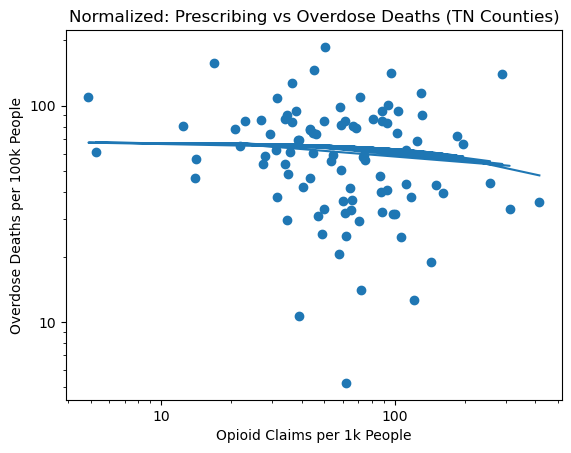

In [44]:
x = county_analysis["claims_per_1k"]
y = county_analysis["deaths_per_100k"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xscale("log")
plt.yscale("log")

# format ticks as plain numbers
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.gca().xaxis.set_minor_formatter(ticker.NullFormatter())
plt.gca().yaxis.set_minor_formatter(ticker.NullFormatter())

plt.xlabel("Opioid Claims per 1k People")
plt.ylabel("Overdose Deaths per 100k People")
plt.title("Normalized: Prescribing vs Overdose Deaths (TN Counties)")


#plt.show()

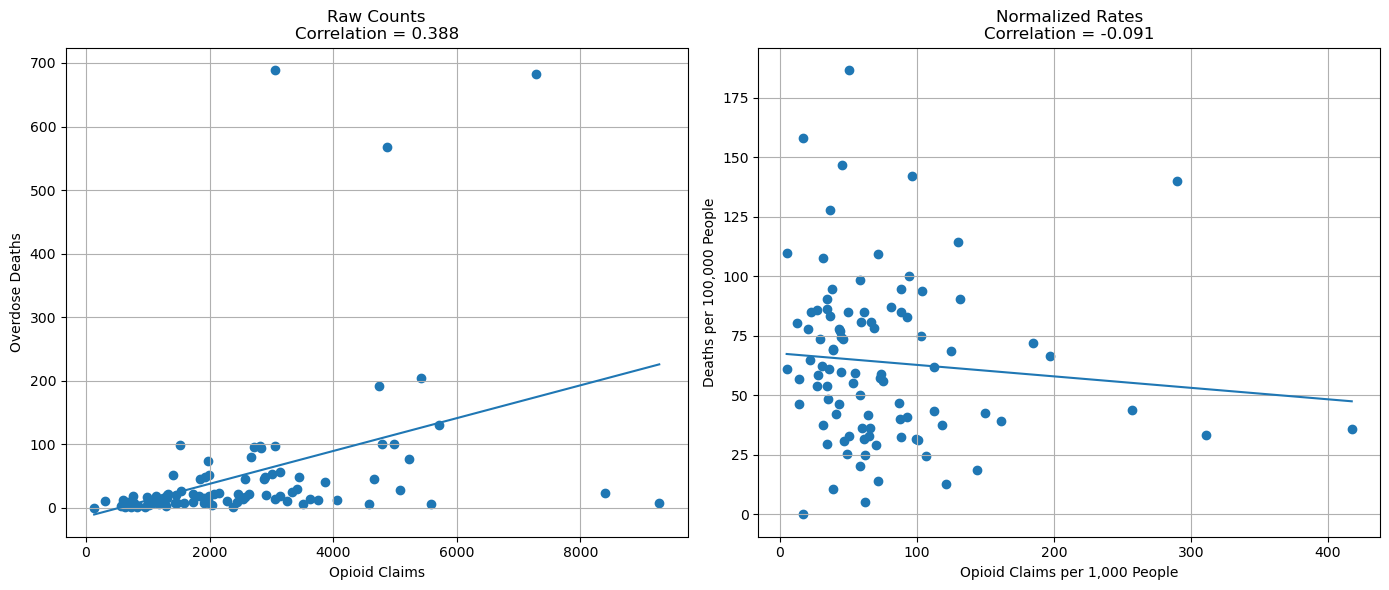

In [45]:
# raw
x_raw = county_analysis["weighted_claims"]
y_raw = county_analysis["overdose_deaths"]
m_raw, b_raw = np.polyfit(x_raw, y_raw, 1)
corr_raw = x_raw.corr(y_raw)
x_raw_sorted = np.sort(x_raw)

# normalized
x_norm = county_analysis["claims_per_1k"]
y_norm = county_analysis["deaths_per_100k"]
m_norm, b_norm = np.polyfit(x_norm, y_norm, 1)
corr_norm = x_norm.corr(y_norm)
x_norm_sorted = np.sort(x_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: raw
axes[0].scatter(x_raw, y_raw)
axes[0].plot(x_raw_sorted, m_raw * x_raw_sorted + b_raw)
axes[0].set_xlabel("Opioid Claims")
axes[0].set_ylabel("Overdose Deaths")
axes[0].set_title(f"Raw Counts\nCorrelation = {corr_raw:.3f}")
axes[0].grid()

# right: normalized
axes[1].scatter(x_norm, y_norm)
axes[1].plot(x_norm_sorted, m_norm * x_norm_sorted + b_norm)
axes[1].set_xlabel("Opioid Claims per 1,000 People")
axes[1].set_ylabel("Deaths per 100,000 People")
axes[1].set_title(f"Normalized Rates\nCorrelation = {corr_norm:.3f}")
axes[1].grid()

plt.tight_layout()
plt.show()

# Money 

In [46]:
### query joined rx and drug names for opioid flag and cost
q_rx = """
    select *
    from prescription p
    join drug d
    using("drug_name");
"""

with engine.connect() as connection:
    rx = pd.read_sql(text(q_rx), con = connection) 
    
rx

,drug_name,npi,bene_count,total_claim_count,total_30_day_fill_count,total_day_supply,total_drug_cost,bene_count_ge65,bene_count_ge65_suppress_flag,total_claim_count_ge65,ge65_suppress_flag,total_30_day_fill_count_ge65,total_day_supply_ge65,total_drug_cost_ge65,generic_name,opioid_drug_flag,long_acting_opioid_drug_flag,antibiotic_drug_flag,antipsychotic_drug_flag
0,RALOXIFENE HCL,1.427076e+09,NaN,18.0,28.0,840.0,1009.66,NaN,*,18.0,None,28.0,840.0,1009.66,RALOXIFENE HCL,N,N,N,N
1,GLIMEPIRIDE,1.003858e+09,NaN,12.0,16.0,480.0,270.86,NaN,*,NaN,*,NaN,NaN,NaN,GLIMEPIRIDE,N,N,N,N
2,TAMSULOSIN HCL,1.184627e+09,NaN,14.0,24.0,698.0,353.62,NaN,#,NaN,#,NaN,NaN,NaN,TAMSULOSIN HCL,N,N,N,N
3,SPIRIVA,1.306111e+09,NaN,13.0,13.0,390.0,4783.28,NaN,*,NaN,*,NaN,NaN,NaN,TIOTROPIUM BROMIDE,N,N,N,N
4,SPIRIVA,1.285658e+09,NaN,13.0,13.0,390.0,4855.95,NaN,#,NaN,#,NaN,NaN,NaN,TIOTROPIUM BROMIDE,N,N,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705010,PROMETHAZINE HCL,1.336170e+09,NaN,11.0,11.0,56.0,62.82,NaN,*,NaN,*,NaN,NaN,NaN,PROMETHAZINE HCL,N,N,N,N
705011,RANITIDINE HCL,1.679676e+09,53.0,178.0,426.0,12760.0,2860.16,NaN,#,NaN,#,NaN,NaN,NaN,RANITIDINE HCL,N,N,N,N
705012,DIAZEPAM,1.265588e+09,16.0,48.0,48.0,1425.0,253.49,NaN,*,14.0,None,14.0,420.0,55.49,DIAZEPAM,N,N,N,N
705013,RAMIPRIL,1.144212e+09,NaN,38.0,90.0,2700.0,627.50,NaN,#,NaN,#,NaN,NaN,NaN,RAMIPRIL,N,N,N,N


In [47]:
opioid_money = rx[rx["opioid_drug_flag"] == "Y"]["total_drug_cost"].sum()
non_opioid_money = rx[rx["opioid_drug_flag"] == "N"]["total_drug_cost"].sum()

ratio = opioid_money / non_opioid_money

print(f"opioid $     : {opioid_money:,.2f}\nnon opioid $ : {non_opioid_money:,.2f}\nratio        : {ratio}")

opioid $     : 105,080,626.37
non opioid $ : 3,011,133,831.49
ratio        : 0.03489736167522083


In [48]:
total_spend = opioid_money + non_opioid_money
opioid_pct = opioid_money / total_spend
non_opioid_pct = non_opioid_money / total_spend

print(f"total        : ${total_spend:,.2f}\nopioid %     : {opioid_pct}\nnon opioid % : {non_opioid_pct}")

total        : $3,116,214,457.86
opioid %     : 0.03372060164375275
non opioid % : 0.9662793983562473
